Name: Leighton Flanagan

Labpartner(s)

In [2]:
#import statements go here
import matplotlib.pyplot as plt
import numpy as np
import netCDF4
import h5netcdf

# Class 6.1

Today we will start with fiunction sharing and do more matplotlib.

# Warmups 6.1

**W.1** Write a function that loops through a list of numbers and checks if they are odd or even, then returns a new list of "odd" or "even" for each element in the input list. For example:

Given the list [3,8,7] the function would return
["odd", "even", "odd"]

In [2]:
def evens_or_odds(number_list):
    "Takes a list of numbers and returns a new list telling whether each number is even or odd"
    new_list = []
    for i in number_list:
        if i % 2 == 0: 
            new_list.append("even")
        else:
            new_list.append("odd")
    return new_list

In [3]:
evens_or_odds?

Signature: evens_or_odds(number_list)
Docstring: Takes a list of numbers and returns a new list telling whether each number is even or odd
File:      c:\users\leigh\appdata\local\temp\ipykernel_37116\762862538.py
Type:      function

In [4]:
numbers = [3,8,7]
check = evens_or_odds(numbers)
print(check)

['odd', 'even', 'odd']


# Lecture 6.1

### Agenda:

- Show us your functions
- Questions
- xarray package and plotting netcdf files


### Show us your functions (from Lab 5.2) - first 5 people today, the rest on Thursday

### Questions

### Loading and plotting netcdf files using xarray

Most modeling data output is in the form of netcdf files, as they can store more data (in binary) using less memory. Netcdf files are great because they tell you all about what is in the file (the variables and their units) with their metadata, which is kind of like the docstring we made for our function. There are a number of command line (unix-based) utilities for dealing with netcdf files, which I am not planning to cover in this course (though I use these all the time). Hit me up if you want some tutorials on this, or if enough of you are keen I will put some unix tutorials in the schedule.

Xarray is a python package that does analysis and basic plotting of netcdf files. This is actively being developed by folks like the pangeo consortium (https://pangeo.io), which is creating a number of python utilities for big data geoscience, like dealing with massive amounts of climate model output. There are other packages that can be used for parsing netcdf files, but they are cumbersome and clunky. Trust me, xarray is the best thing since sliced bread for big data geoscience. 

Let's grab some data and start playing with it. We are going to use the HYCOM Gulf of Mexico Analysis output, which is basically weather prediction for our local ocean made by the Navy, freely available. https://www.hycom.org.

In [3]:
import xarray as xr
#!pip install netCDF4 h5netcdf
# make sure you also have nectdf4 installed!

We want the HYCOM GoM reanalysis product: https://www.hycom.org/dataserver/gom/gom-reanalysis
And we are going to use the coarser resolution (1/25 degree) version for computational speed.

Which we can get using the opendap link (see http://xarray.pydata.org/en/stable/io.html)

In [16]:
# here I am going to grab the hindcast they made for Jan 1 2001. 
# Note I had to add the http: in front of the opendap link (see "open data here" button)

# download from the internet

# or download the file by clicking on the https server link and putting the correct path
file_path="2001_020_archv.2001_016_01_2d.nc4"

In [18]:
#hycom_data = xr.open_dataset(link, decode_times=False)

hycom_data = xr.open_dataset(file_path, decode_times=False)

# honestly I don't know why you need the decode_times bit with open_dataset
# I just know it doesn't work most of the time if you leave it out (bonus token for anyone who figures it out!)

The result is an xarray dataset, which is similar to the pandas dataframes you have been using. It has dimensions, coordinates and variables. The first thing to do when you get a dataset is to figure out what is in it and explore it a bit. 

In [ ]:
hycom_data

In [8]:
hycom_data2

<xarray.Dataset> Size: 5MB
Dimensions:                (MT: 1, Latitude: 385, Longitude: 525)
Coordinates:
  * MT                     (MT) float64 8B 3.653e+04
  * Latitude               (Latitude) float32 2kB 18.09 18.13 ... 31.93 31.96
  * Longitude              (Longitude) float32 2kB -98.0 -97.96 ... -77.04
Data variables:
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 808kB ...
    ssh                    (MT, Latitude, Longitude) float32 808kB ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    wnd_ewd                (MT, Latitude, Longitude) float32 808kB ...
    wnd_nwd                (MT, Latitude, Longitude) float32 808kB ...
Attributes:
    title:               HYCOM
    source:              HYCOM archive file
    experiment:          01.0
    history:             python
    Conventions:         CF-1.0
    History:             Translated to CF-1.0 Conventions by Netcdf-Java CDM ...
    geospatial_lat_min:  18.09164810180664
    geospatial_lat_max:  31.960647583007812
    geospatial_lon_min:  -98.0
    geospatial_lon_max:  -77.04000091552734

This is the 2D surface variable file. I really want SST, so I think I'm going to need the 3D file

In [24]:
# get the 3D file and see what's in it

# download from the internet
file_path2 = "2001_020_archv.2001_016_01_3z.nc4"
hycom_data_3D = xr.open_dataset(file_path2, decode_times=False)

In [25]:
hycom_data_3D

<xarray.Dataset> Size: 162MB
Dimensions:     (MT: 1, Depth: 40, Latitude: 385, Longitude: 525)
Coordinates:
  * MT          (MT) float64 8B 3.654e+04
  * Depth       (Depth) float32 160B 0.0 2.0 4.0 6.0 ... 3e+03 4e+03 5e+03
  * Latitude    (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude   (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Data variables:
    salinity    (MT, Depth, Latitude, Longitude) float32 32MB ...
    u           (MT, Depth, Latitude, Longitude) float32 32MB ...
    v           (MT, Depth, Latitude, Longitude) float32 32MB ...
    w_velocity  (MT, Depth, Latitude, Longitude) float32 32MB ...
    water_temp  (MT, Depth, Latitude, Longitude) float32 32MB ...
Attributes:
    Conventions:         CF-1.0
    source:              HYCOM archive file
    experiment:          01.0
    history:             python
    title:               HYCOM
    History:             Translated to CF-1.0 Conventions by Netcdf-Java CDM ...
    geospatial_lat_min:  18.09164810180664
    geospatial_lat_max:  31.960647583007812
    geospatial_lon_min:  -98.0
    geospatial_lon_max:  -77.04000091552734

In [19]:
# what is the lat spacing and domain?

hycom_data.Latitude

# looks like it goes from 18.09 N to 31.96 N and the spacing is 0.04 degrees, i.e. 1/25, so that checks
# 1 degree is about 100 km, so thats 4 km model resolution

<xarray.DataArray 'Latitude' (Latitude: 385)> Size: 2kB
array([18.091648, 18.129667, 18.167677, ..., 31.892748, 31.926704, 31.960648],
      dtype=float32)
Coordinates:
  * Latitude  (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
Attributes:
    standard_name:        latitude
    units:                degrees_north
    axis:                 Y
    _CoordinateAxisType:  Lat

In [20]:
# what about lon?
hycom_data.Longitude

<xarray.DataArray 'Longitude' (Longitude: 525)> Size: 2kB
array([-98.  , -97.96, -97.92, ..., -77.12, -77.08, -77.04], dtype=float32)
Coordinates:
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    standard_name:        longitude
    units:                degrees_east
    point_spacing:        even
    axis:                 X
    _CoordinateAxisType:  Lon

### Basic plotting with xarray (not publication ready!)

In [60]:
(hycom_data.ssh)

<xarray.DataArray 'ssh' (MT: 1, Latitude: 385, Longitude: 525)> Size: 808kB
array([[[1.267651e+30, 1.267651e+30, ..., 1.267651e+30, 1.267651e+30],
        [1.267651e+30, 1.267651e+30, ..., 1.267651e+30, 1.267651e+30],
        ...,
        [1.267651e+30, 1.267651e+30, ..., 1.267651e+30, 1.267651e+30],
        [1.267651e+30, 1.267651e+30, ..., 1.267651e+30, 1.267651e+30]]],
      dtype=float32)
Coordinates:
  * MT         (MT) float64 8B 3.654e+04
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    long_name:       sea surf. height  [01.0H]
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-1.5058999  0.3235744]

Note that one of the amazing things about xarray, is that it actually does not go and get the data until you call for it, so this will take a minute to upload.

In [54]:
ssh_array = np.array(hycom_data.ssh)

In [55]:
ssh_array[ssh_array > 0.4] = np.nan

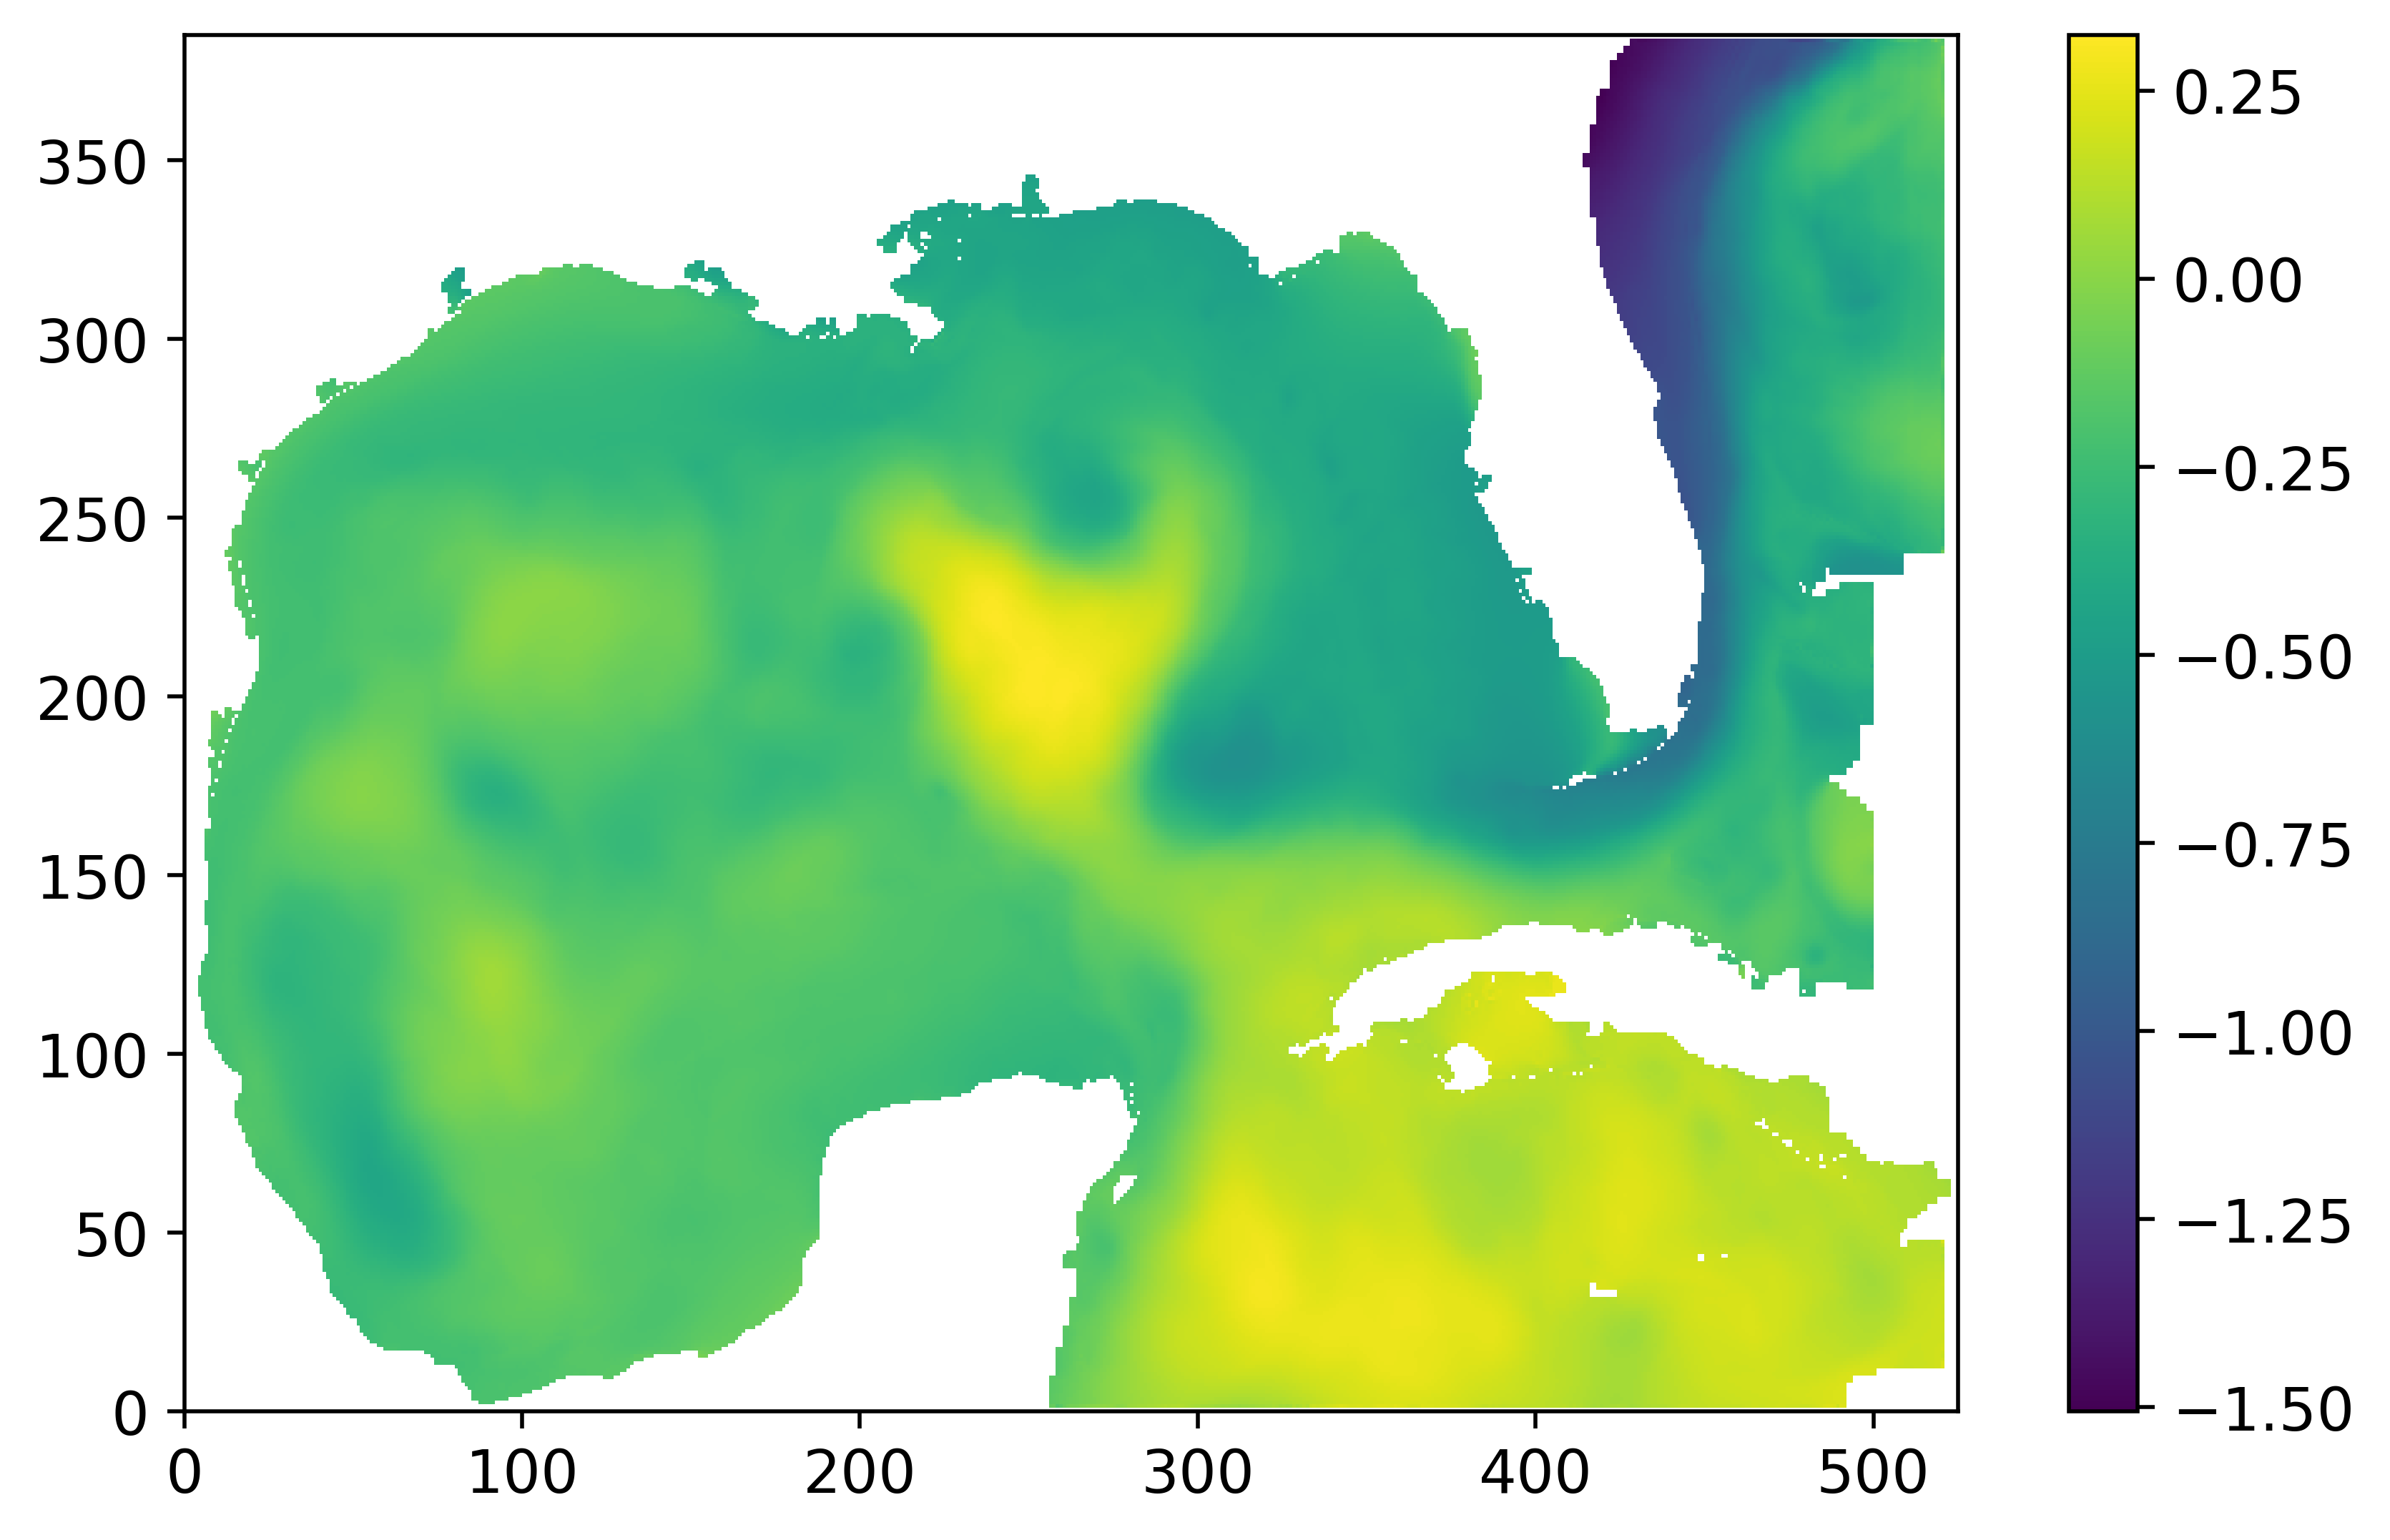

In [61]:
p = plt.pcolormesh(ssh_array[0])
plt.colorbar(p)

Note that xarray, like pandas, uses matplotlib for plotting, and that it figured out to use the blue to red colormap based on the type of data. Pretty cool. 

Let's plot some temperature data and see how it compares. Since temperature data is given for the whole depth, we have to select a level.

water_temp
(MT, Depth, Latitude, Longitude)

In [26]:
hycom_data_3D.water_temp[0,0,:,:]

<xarray.DataArray 'water_temp' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
    MT         float64 8B 3.654e+04
    Depth      float32 4B 0.0
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    long_name:      temp [01.0H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.3400404 26.8434459]

In [65]:
type(hycom_data_3D.water_temp)

xarray.core.dataarray.DataArray

In [83]:
water_temp_array = np.array(hycom_data_3D.water_temp[0,0,:,])

In [79]:
print(water_temp_array)

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [84]:
water_temp_array[water_temp_array > 27] = np.nan

In [85]:
np.isnan(water_temp_array).all()

np.False_

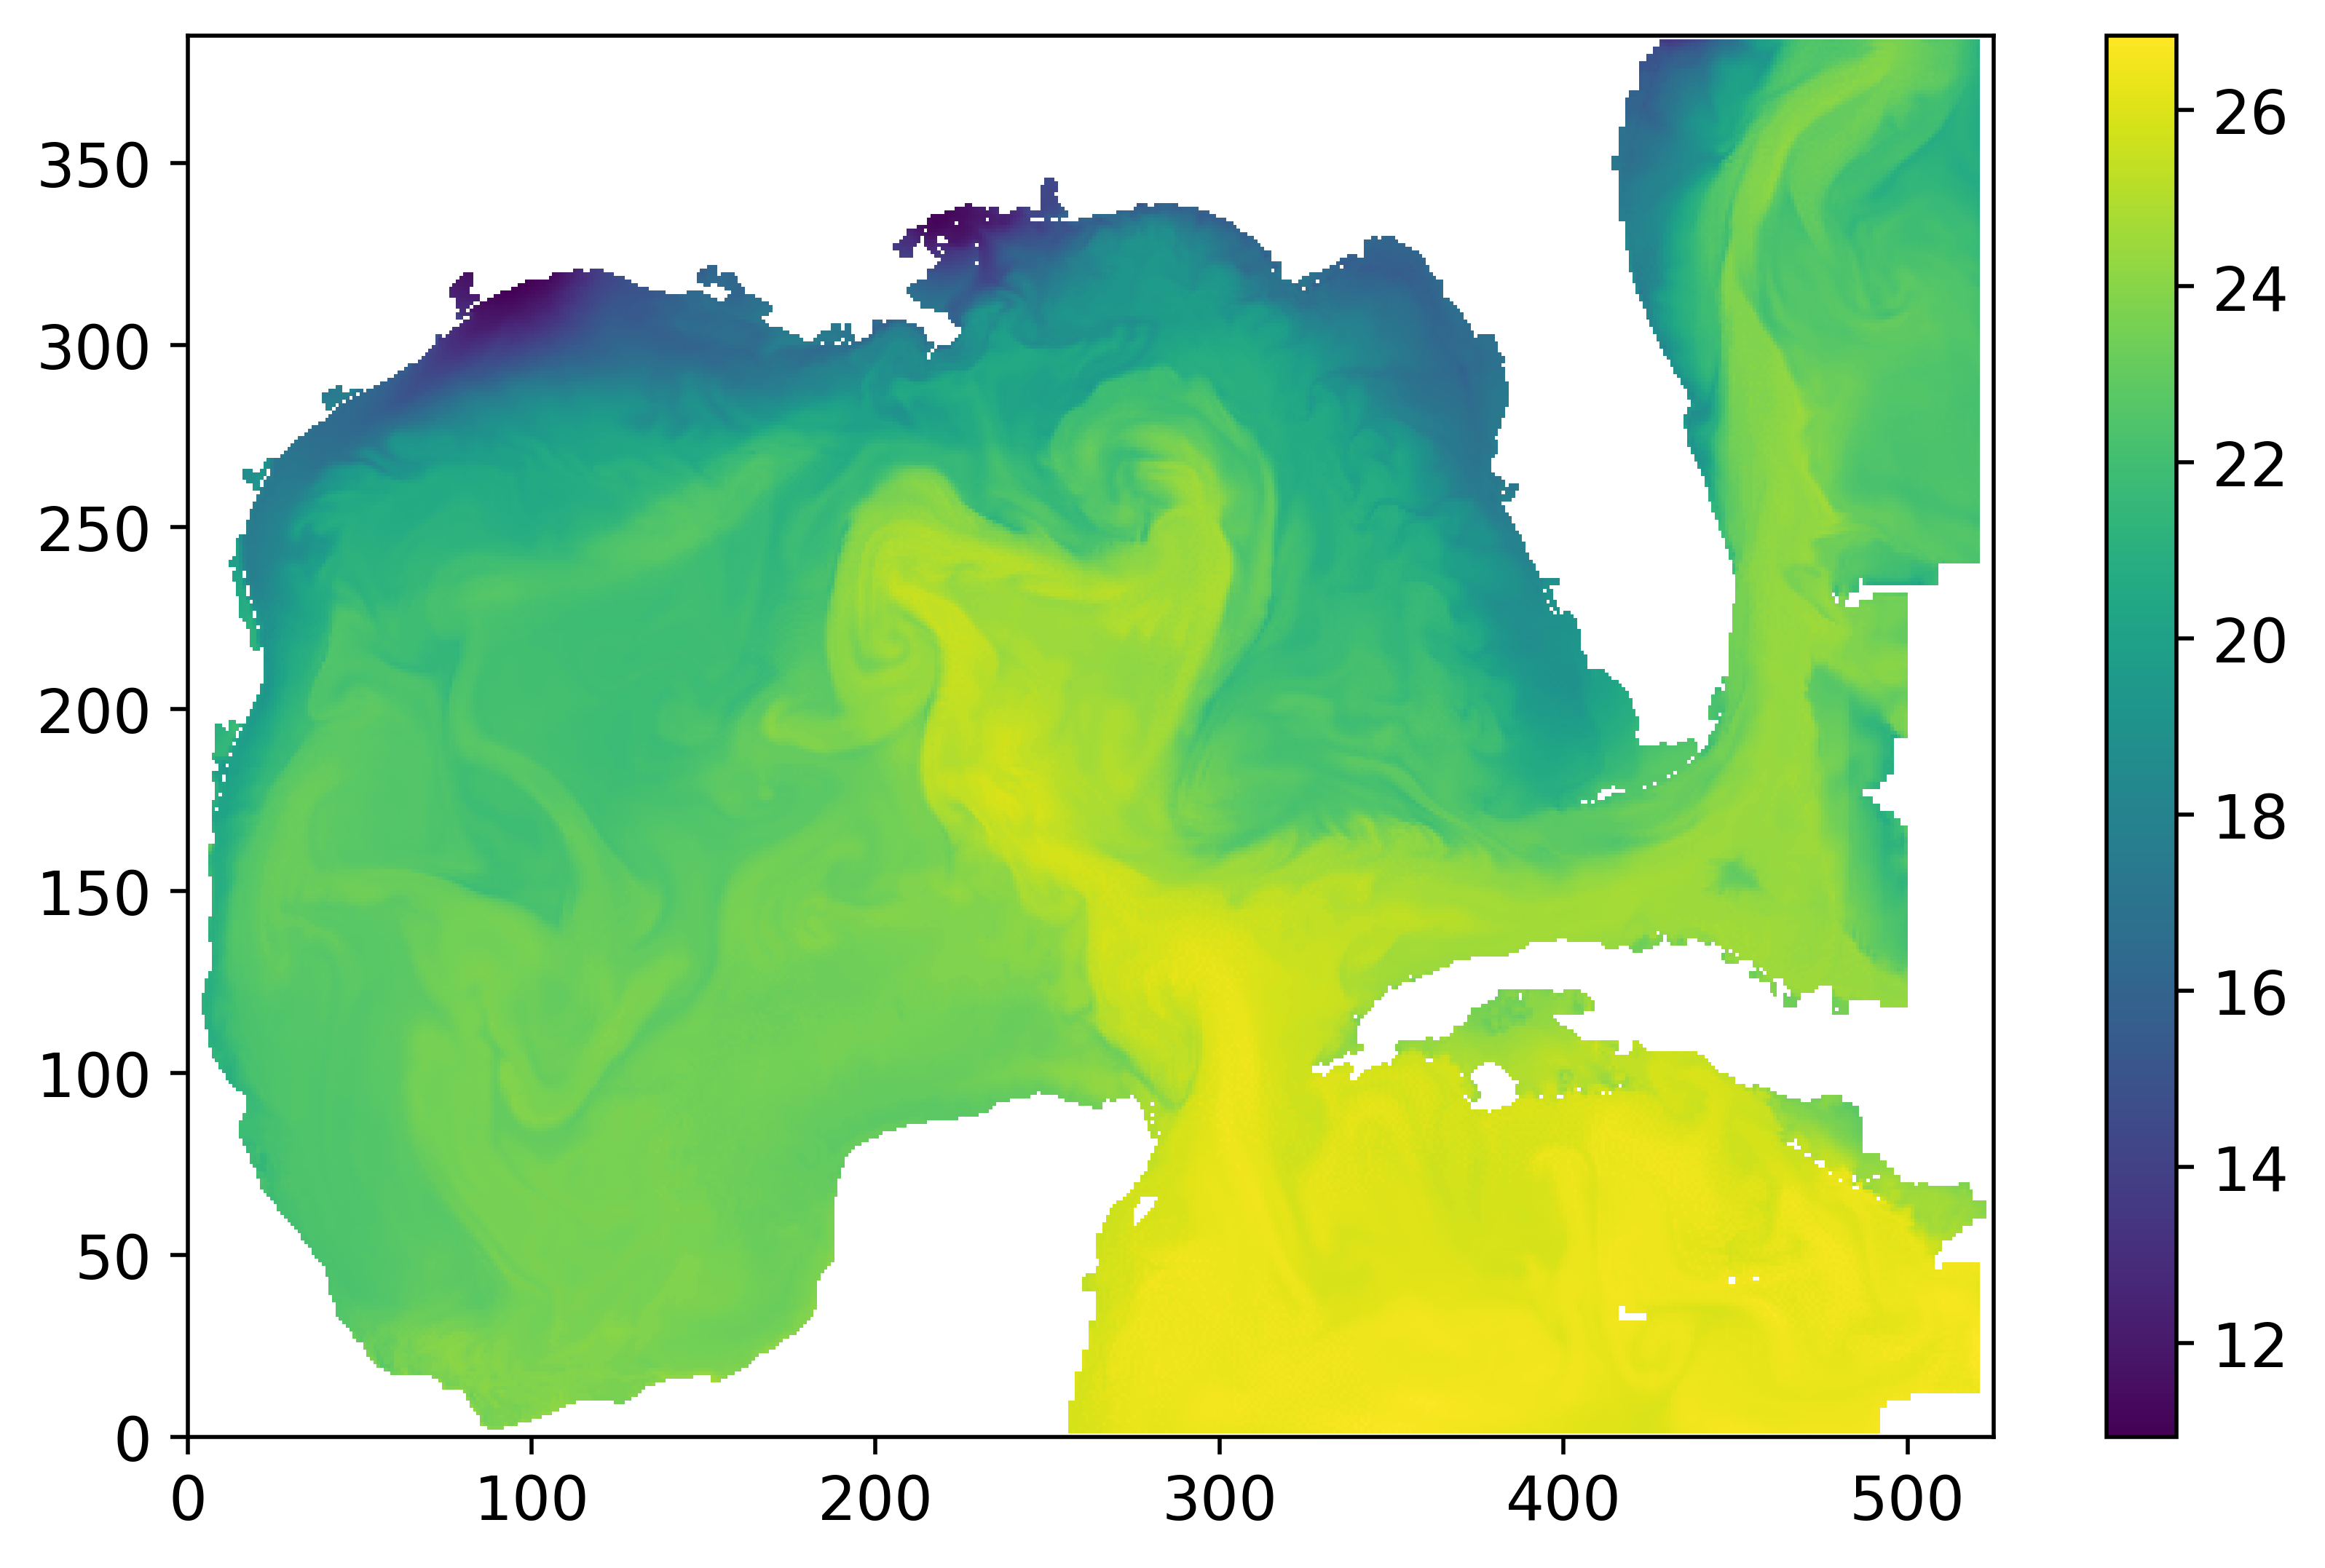

In [86]:
pl = plt.pcolormesh(water_temp_array[:])
plt.colorbar(pl)

In [88]:
water_temp_array2 = np.array(hycom_data_3D.water_temp[0,19,:,])

In [93]:
water_temp_array2[water_temp_array2 > 27] = np.nan

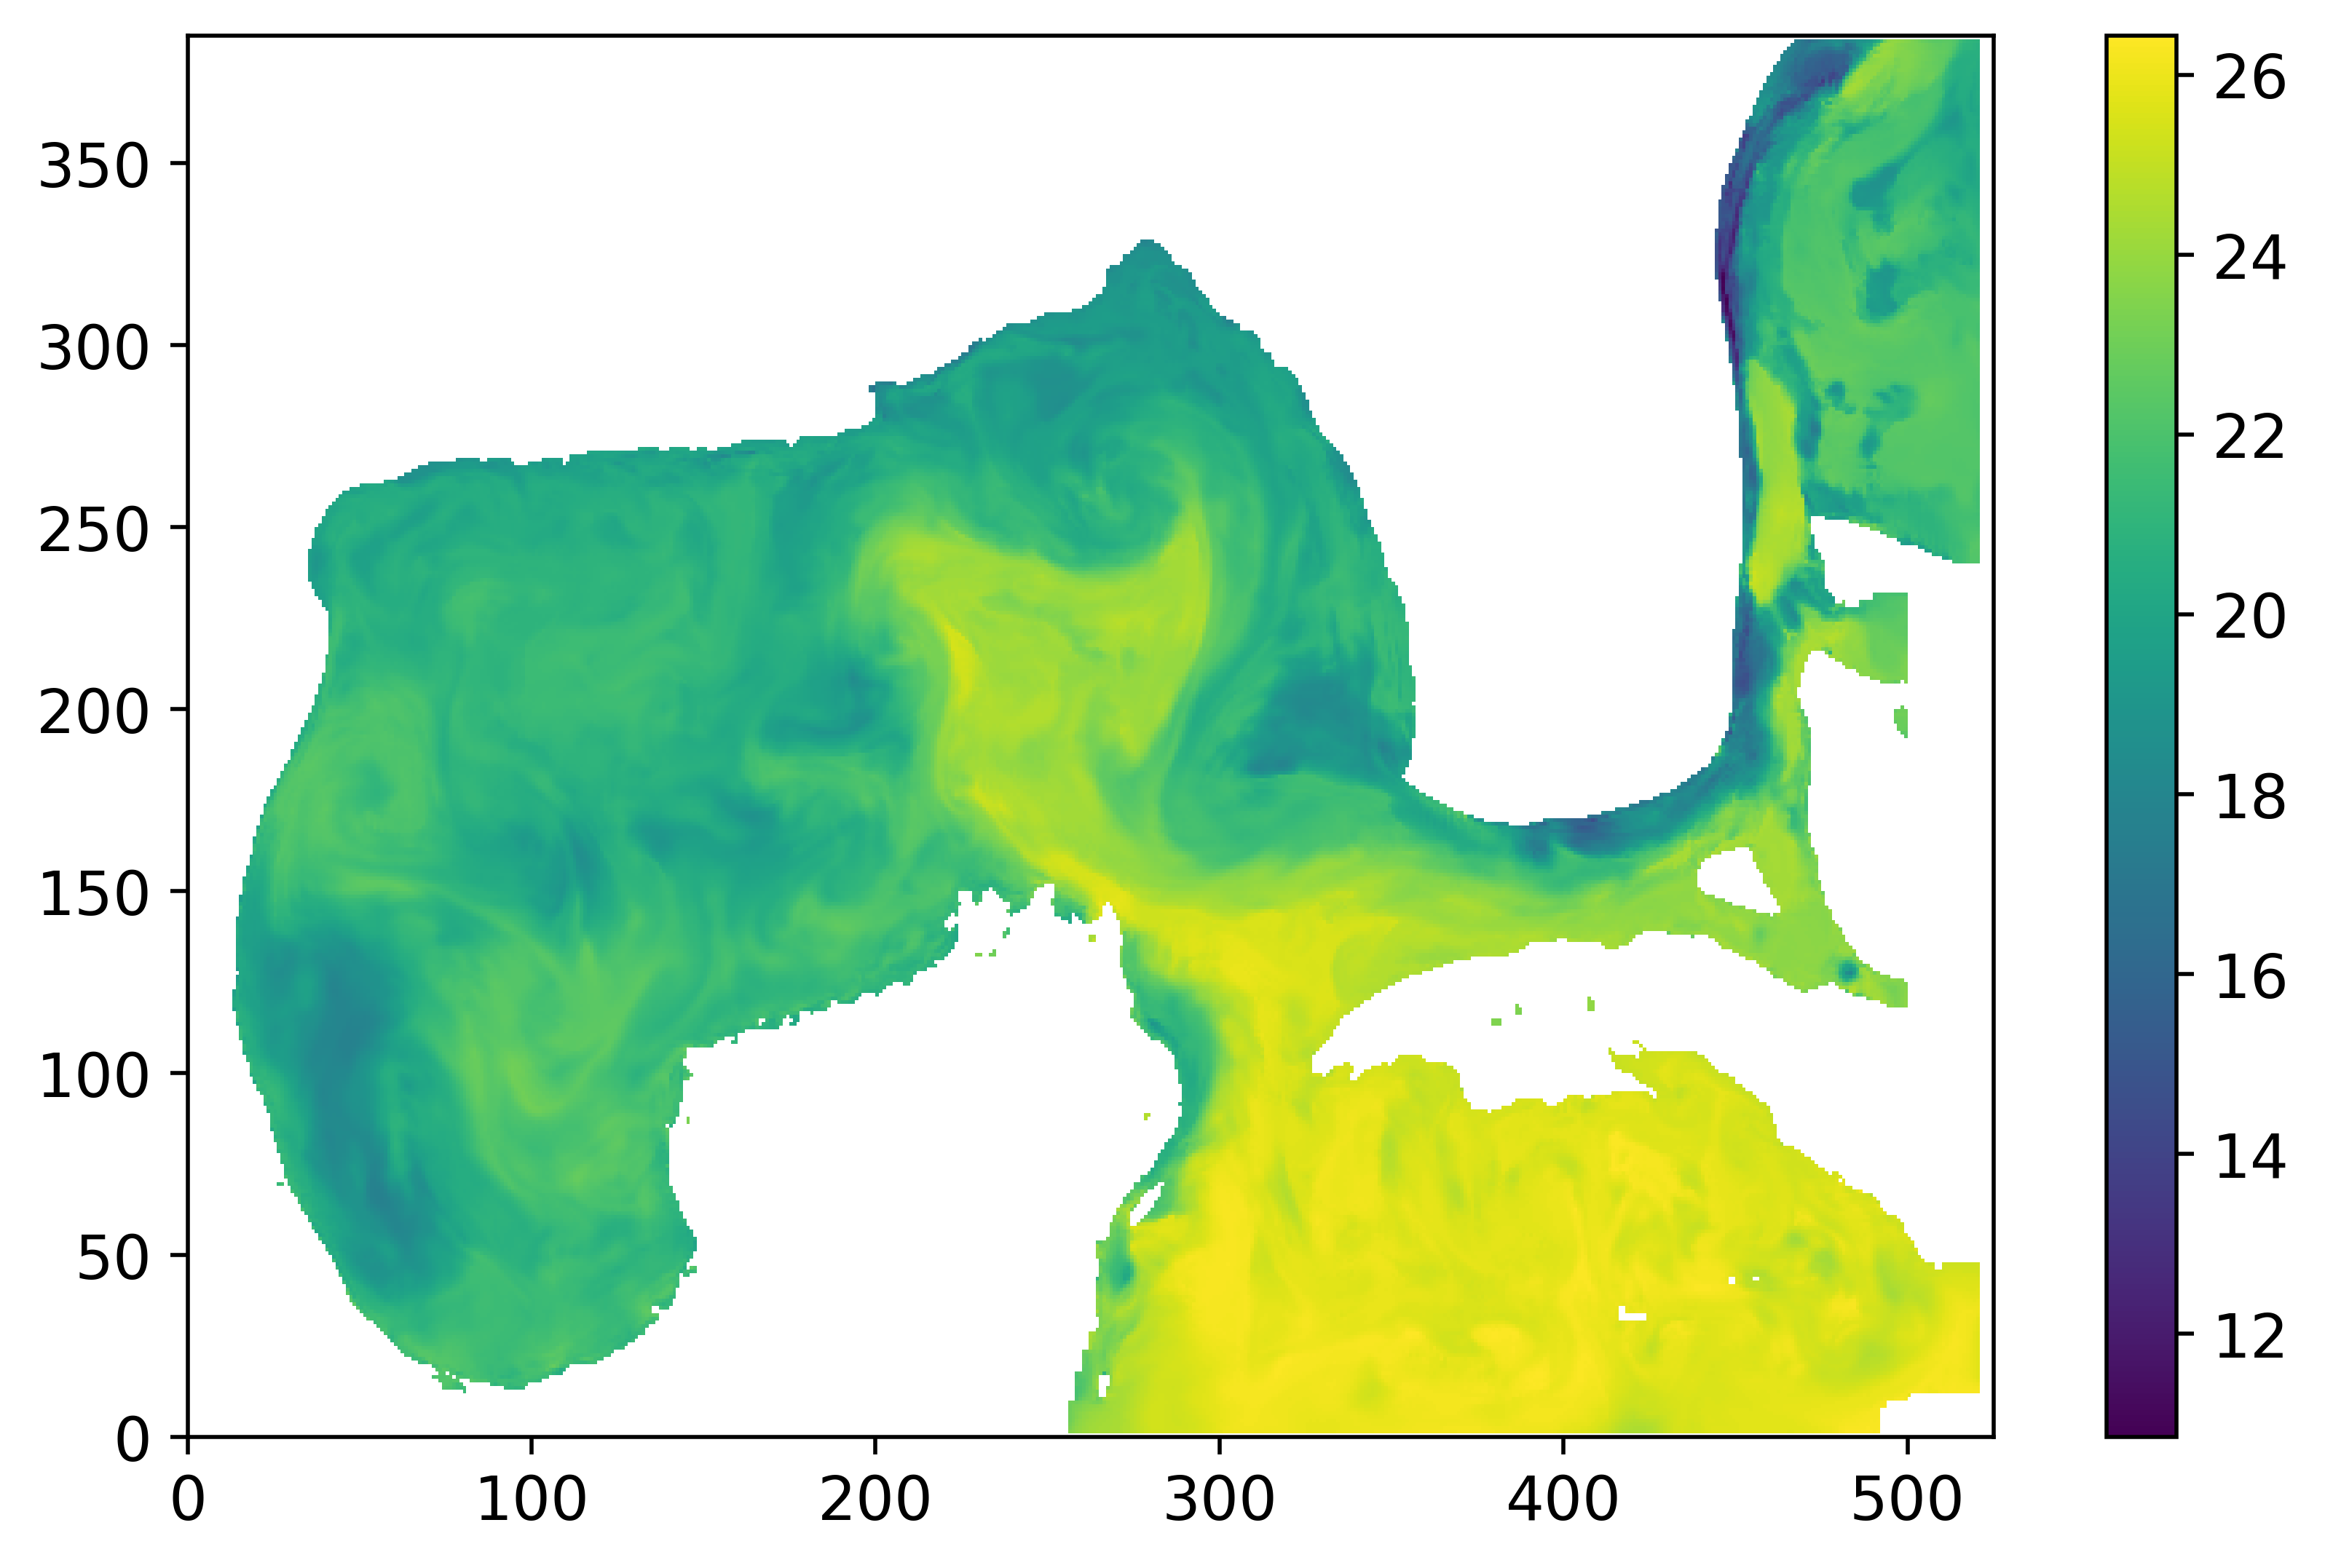

In [94]:
pl2 = plt.pcolormesh(water_temp_array2)
plt.colorbar(pl2)

Those plots are really small. I like to change the default matplotlib preferences to make my plots bigger.

In [9]:
# change all the defaults (usually I stick this up with the import statements)

import matplotlib as mpl
mpl.rcParams['figure.figsize'] = [8.0, 5.0]
mpl.rcParams['figure.dpi'] = 500
mpl.rcParams['savefig.dpi'] = 500

mpl.rcParams['font.size'] = 12
mpl.rcParams['legend.fontsize'] = 'large'
mpl.rcParams['figure.titlesize'] = 'medium'
mpl.rcParams['lines.linewidth']= 2.0

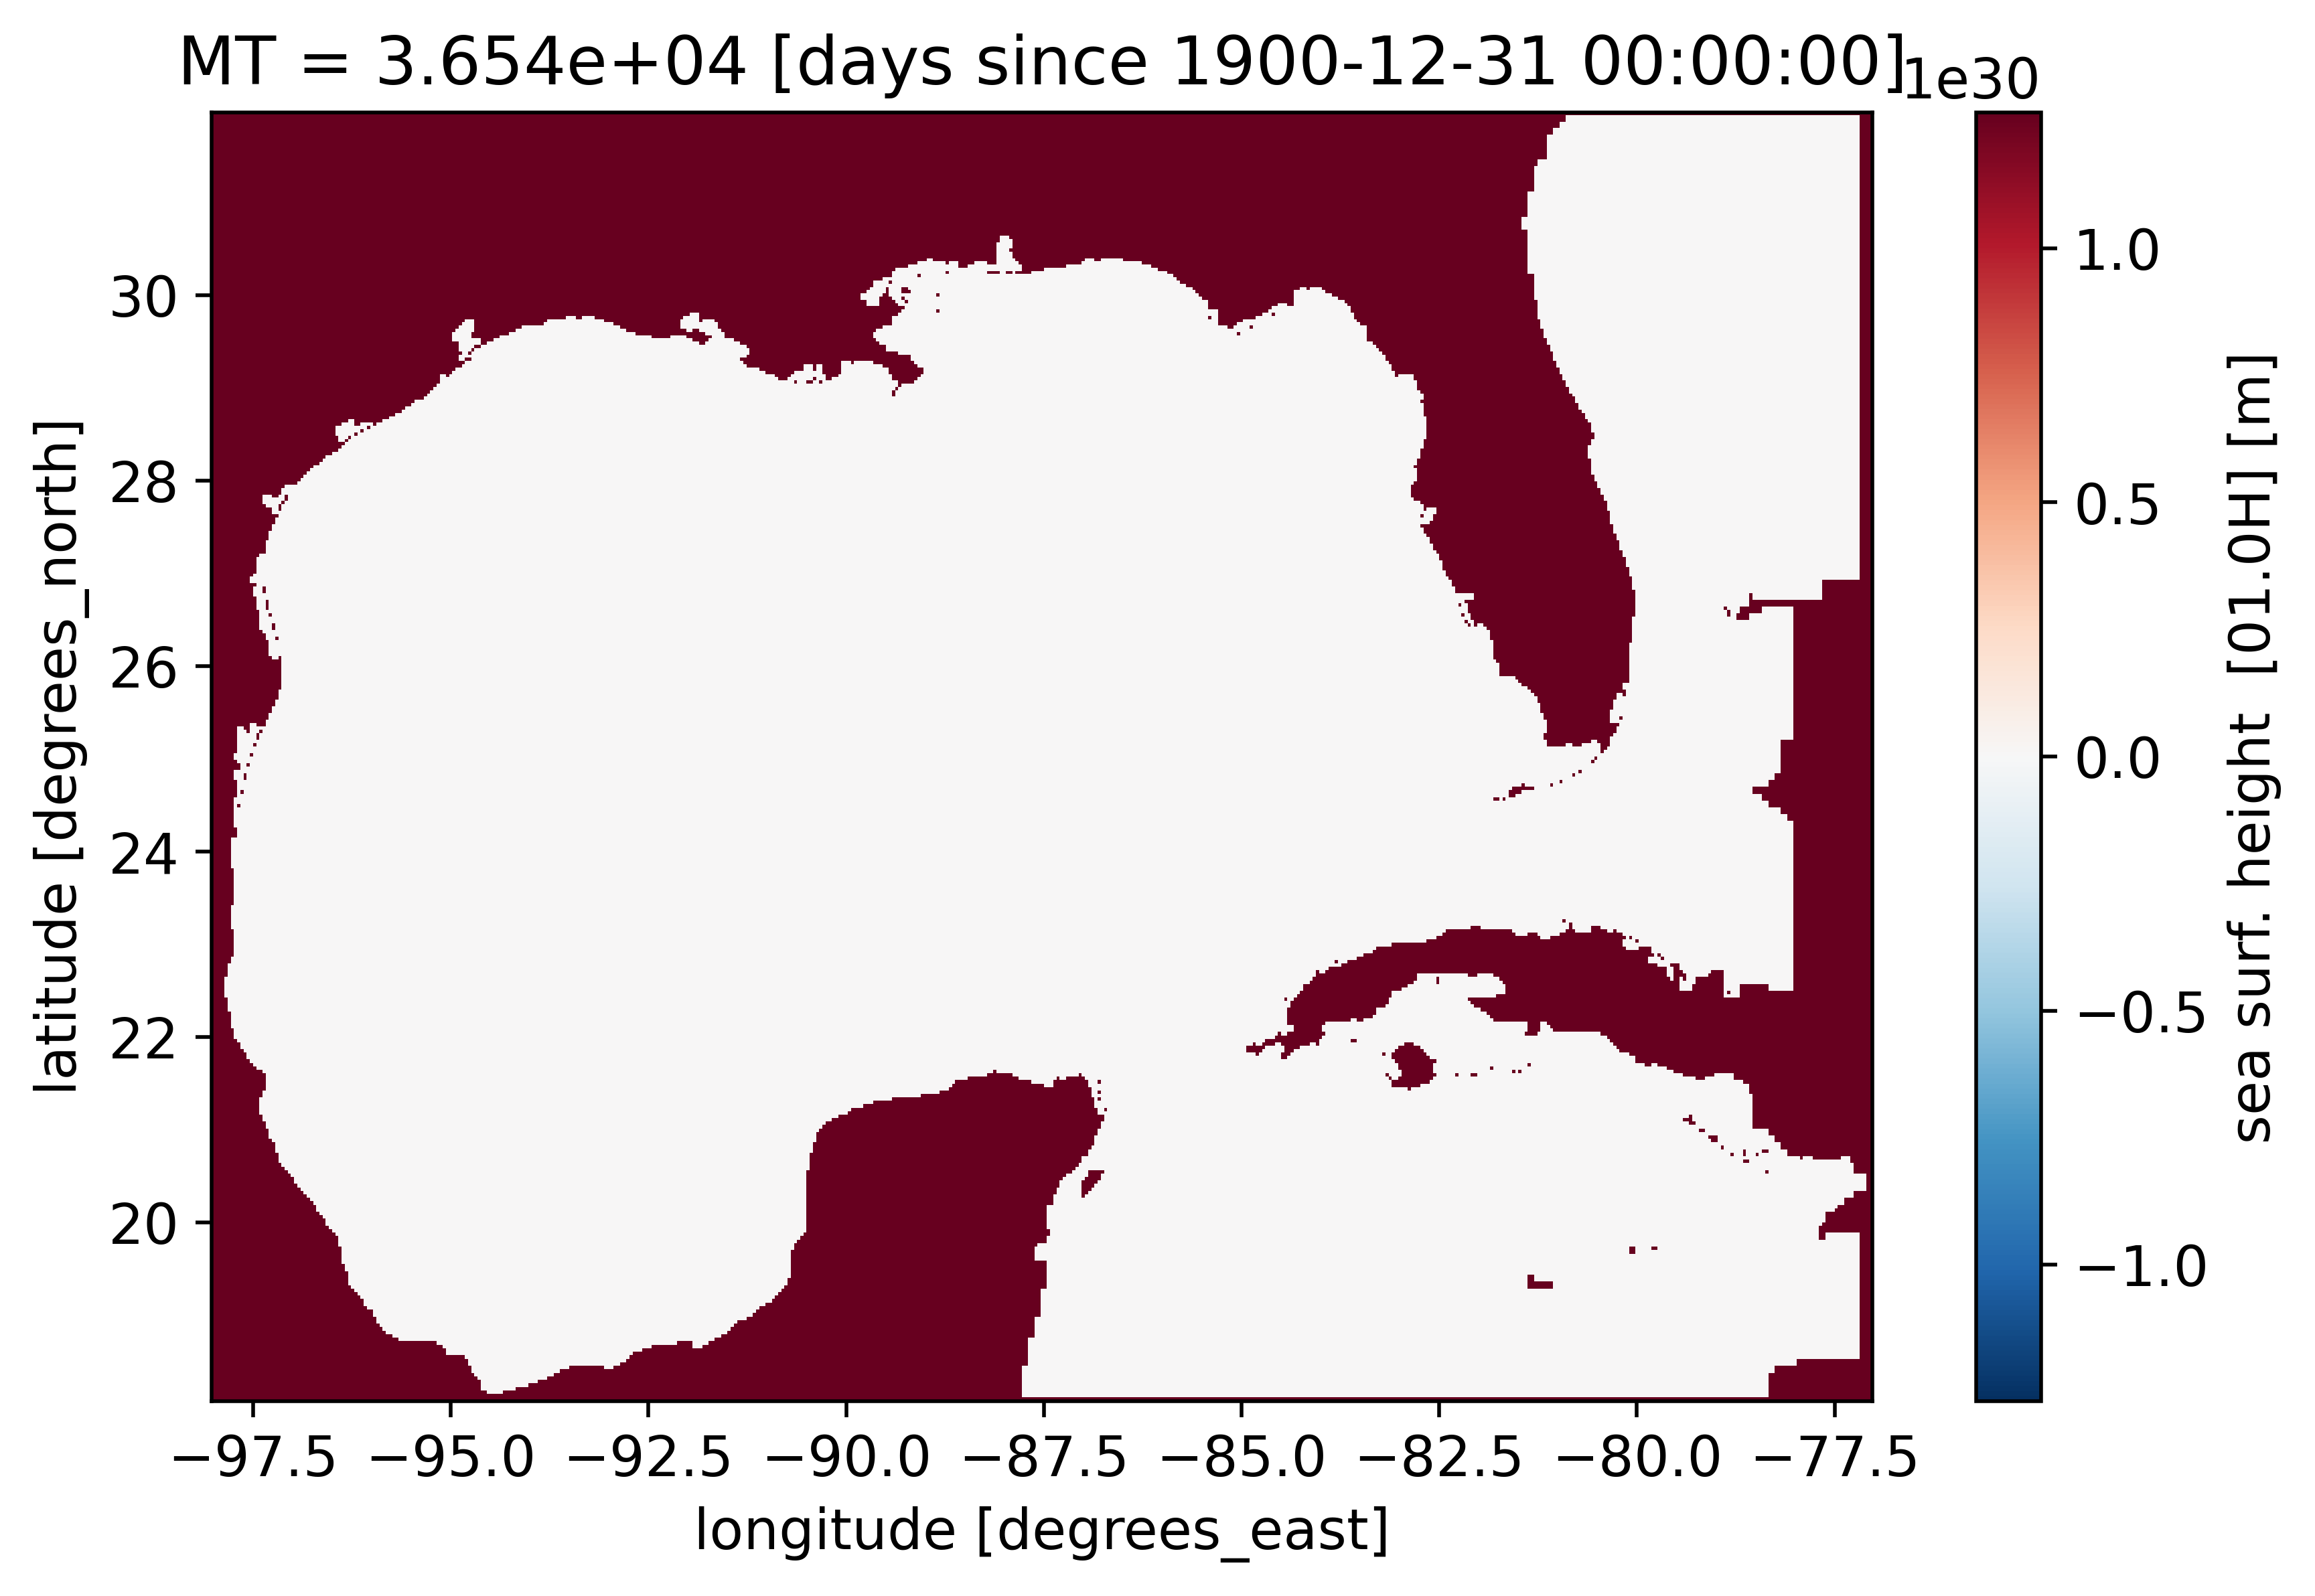

In [30]:
# now it's big and pretty.

hycom_data.ssh.plot()

Note if you know you are going to plot the same bit of data over and over again to fiddle with the plot, you can download the data you need and save it in an array to make the proccess faster.

In [31]:
SST = hycom_data_3D.water_temp[0,0,:,:]

In [32]:
type(SST)

xarray.core.dataarray.DataArray

In [33]:
SST # note it saves all the coordinates I need.

<xarray.DataArray 'water_temp' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
    MT         float64 8B 3.654e+04
    Depth      float32 4B 0.0
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    long_name:      temp [01.0H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.3400404 26.8434459]

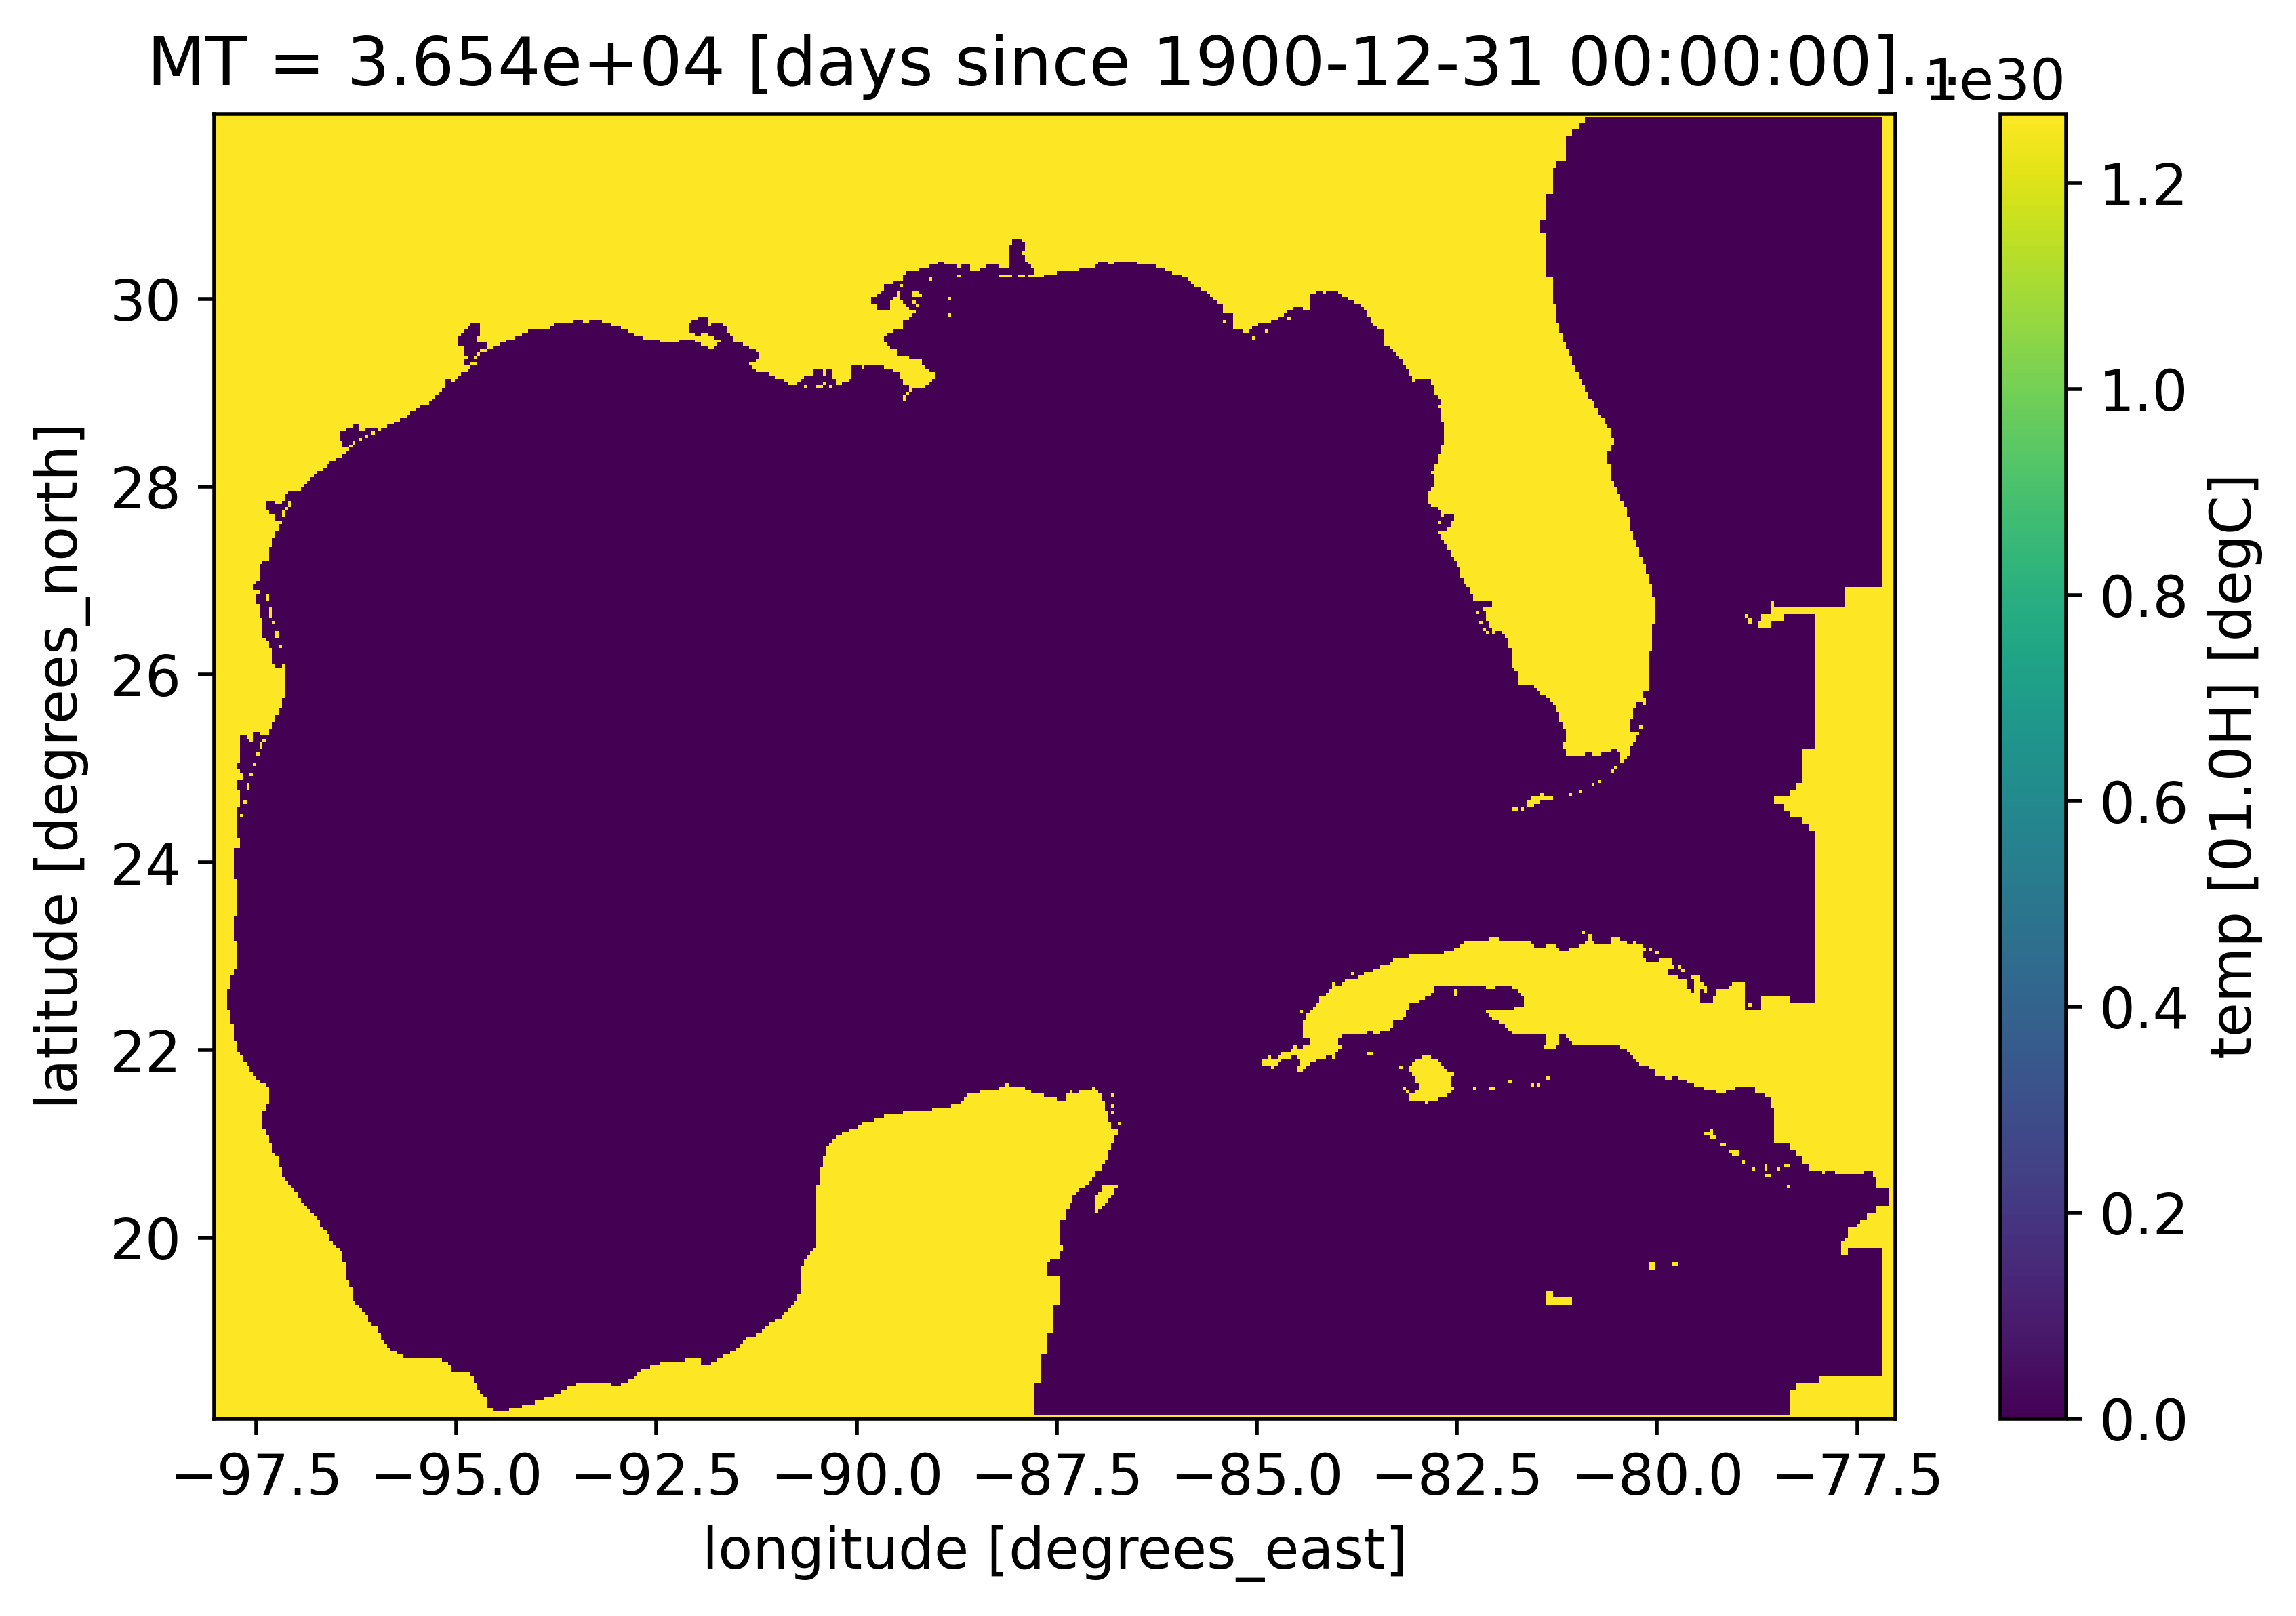

In [34]:
SST.plot()

I can also save this subset of the data to a new netcdf file locally very easily. See http://xarray.pydata.org/en/stable/io.html for more details.

In [35]:
SST.to_netcdf('SST_2001_001_01.nc') # the new netcdf file is saved in the local directory

And then I load in the new netcdf file in the same way as I did the remote data, but using the local filepath

In [36]:
sst_data = xr.open_dataset('SST_2001_001_01.nc', decode_times=False)

In [37]:
sst_data

<xarray.Dataset> Size: 812kB
Dimensions:     (Latitude: 385, Longitude: 525)
Coordinates:
    MT          float64 8B ...
    Depth       float32 4B ...
  * Latitude    (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude   (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Data variables:
    water_temp  (Latitude, Longitude) float32 808kB ...

# Lab 6.1

**E.0** Finish Lab 5.2 if you haven't already.

**E.1** Complete Introduction to Data Visualization with Matplotlib Chapters 1-2. Let me know if this feels like a good pace

**E.2** Make notes for yourself on progamming tecniques and commands you learned in the lecture and datacamp chapter above, including examples, comments and explainitory text. You can do this here or in a separate notebook that you link to here. Basically, you are making a cheat sheet for yourself.

See also http://xarray.pydata.org/en/stable/plotting.html for more info about plotting right from xarray (optional).

### Chapter 1

**Creating a Basic Figure**

Use the code:

fig, ax = plt.subplots()

to create a figure object (the plotting window) and an axes object (contains the data to be plotted). The ax.plot() method is what is used to plot the data. Use plt.show() to show the figure window. Multiple datasets can be plotted in the same figure, and will be if another line like that above isn't specified to created a new set of figure and axes objects.

**Figure Customization**

Figures can be customized in ways like changing colors, changing markers, or changing linestyles. For example, in the ax.plot() method, you can use these modifiers.

color = 'b' (changes color to blue, not sure if this can also be used with RGB triplets like in R)

marker = 'o' (makes the marker for each data point a circle)

linestyle = '--' (makes the trendline dashed)

The axes can be given titles using ax.set_xlabel() (or ylabel), and typing desired text. A title for the entire figure can be added using ax.set_title().

**Small Multiples**

If you'd like to make a figure with subplots, specify the number of plots in the rows/columns of the figure in the plt.subplots() function. For example, plt.subplots(3,2) will create a figure with 6 subplots: 3 rows and 2 columns. Indexing is added when using the ax.plot() function. For example, to index the second plot on the first row of this figure, we would use ax[1,2].plot(). For one dimensional arrays, you only need one indexing number. 

### Chapter 2

**Time Indeces**

When reading in a .csv file that you want to set as a DataTimeIndex, you need to use the parse_dates and index_col arguments.

climate_change = pd.read_csv('climate_change.csv', parse_dates = ['date'], index_col = 0)


To plot, you set the index on the x axis (to represent time), and the data of your choosing on the y axis. You can also pull out a specific chunk of time in the larger dataset and plot just that. To plot two variables of different y values on the same plot, create another axis using ax.twinx(). This can be given its own y variables.

**Annotating Figures**

The ax.annotate() method allows you to add text at a specific place on the axes. First you put the text into the function, then where the text should be, then where the arrow should point. To add the arrows, use arrowprops = {} within the annotate functions. In the arrowprops, alter properties using "arrowstyle":"->", "color":"gray", etc. 



**E.3** Using the lecture as a guide, save the sea surface temperature at ~100 m depth on your birthday in 2019 as a new, local netcdf file. You don't have to submit the file, just the code here.

In [4]:
file_path3="2019_031_archv.2019_126_19_3z.nc4"
hycom_data_3D_bday = xr.open_dataset(file_path3, decode_times=False)

In [5]:
hycom_data_3D_bday.water_temp

<xarray.DataArray 'water_temp' (MT: 1, Depth: 40, Latitude: 385, Longitude: 525)> Size: 32MB
[8085000 values with dtype=float32]
Coordinates:
  * MT         (MT) float64 8B 4.323e+04
  * Depth      (Depth) float32 160B 0.0 2.0 4.0 6.0 ... 3e+03 4e+03 5e+03
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    long_name:      temp [01.0H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.7566151 31.0317045]

**E.4** Plot the above (your 2019 birthday SST) using the basic xarray funcitons

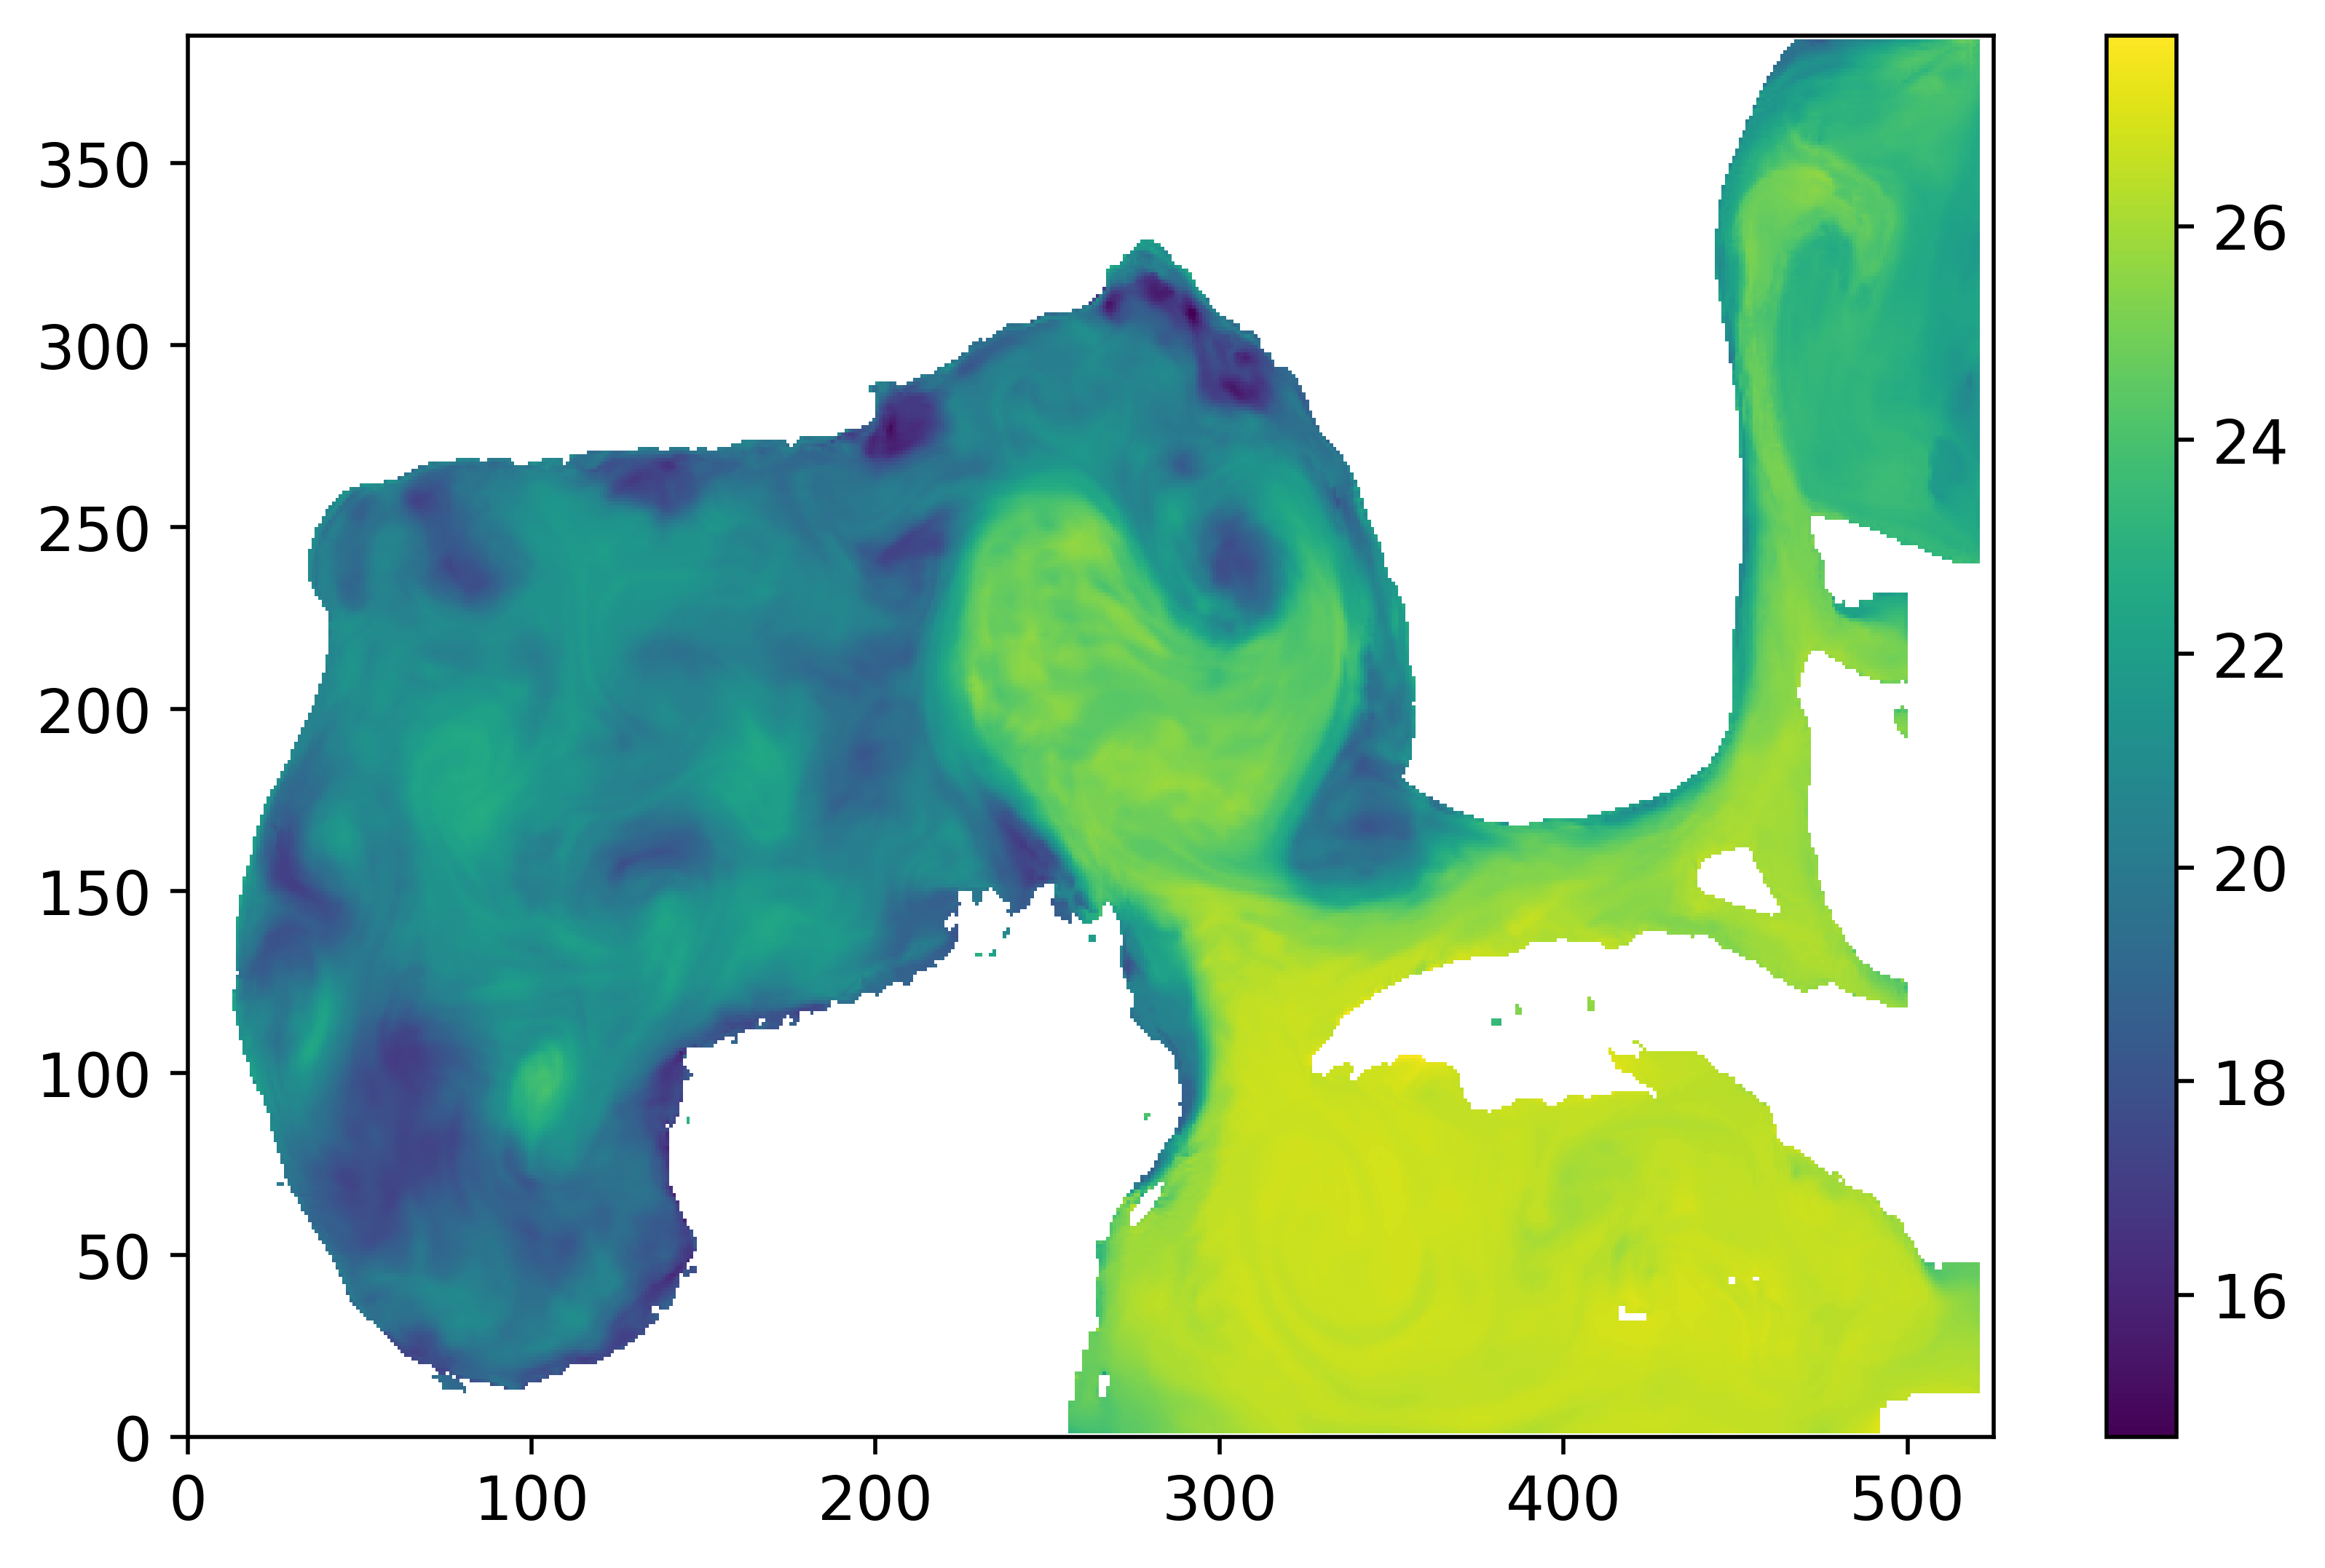

In [10]:
bday_array = np.array(hycom_data_3D_bday.water_temp[0,19,:,])
bday_array[bday_array > 32] = np.nan
bdayplot = plt.pcolormesh(bday_array)
plt.colorbar(bdayplot)

**E.5** What is the SST for flower garden banks national marine sanctuary o

In [39]:
print(hycom_data_3D_bday.water_temp.Latitude[256])

<xarray.DataArray 'Latitude' ()> Size: 4B
array(27.516811, dtype=float32)
Coordinates:
    Latitude  float32 4B 27.52
Attributes:
    standard_name:        latitude
    units:                degrees_north
    axis:                 Y
    _CoordinateAxisType:  Lat


In [37]:
print(hycom_data_3D_bday.water_temp.Longitude[113])

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-93.48, dtype=float32)
Coordinates:
    Longitude  float32 4B -93.48
Attributes:
    standard_name:        longitude
    units:                degrees_east
    point_spacing:        even
    axis:                 X
    _CoordinateAxisType:  Lon


In [41]:
fgb_bday = hycom_data_3D_bday.water_temp[0,0,256,113]
print(fgb_bday)

<xarray.DataArray 'water_temp' ()> Size: 4B
array(24.632582, dtype=float32)
Coordinates:
    MT         float64 8B 4.323e+04
    Depth      float32 4B 0.0
    Latitude   float32 4B 27.52
    Longitude  float32 4B -93.48
Attributes:
    long_name:      temp [01.0H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.7566151 31.0317045]
